✅ Data Loaded Successfully!
Shape: (2216, 64)
    Education  Has_Partner  Income  Recency  Wines  Fruits  Meat  Fish  \
0  Graduation            0   58138       58    635      88   546   172   
1  Graduation            0   46344       38     11       1     6     2   
2  Graduation            1   71613       26    426      49   127   111   

   Sweets  Gold  ...  R_score  F_score  M_score  RFM_Total  log_Income  \
0      88    88  ...      3.0      3.0      5.0       11.0   10.970592   
1       1     6  ...      4.0      3.0      1.0        8.0   10.743869   
2      21    42  ...      4.0      4.0      4.0       12.0   11.179046   

   log_Total_Spent  Income_x_HasPartner  Age_x_WebShare  Age_Bin  Income_q  
0         7.388946                    0       20.727273    45-59         2  
1         3.332205                    0       15.000000      60+         2  
2         6.655440                71613       19.600000    45-59         3  

[3 rows x 64 columns]

Categorical Columns: ['Educa

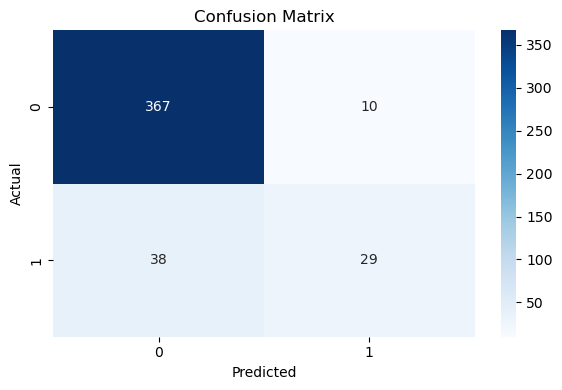

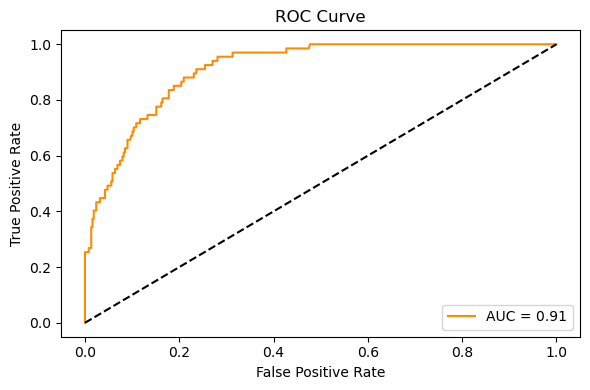

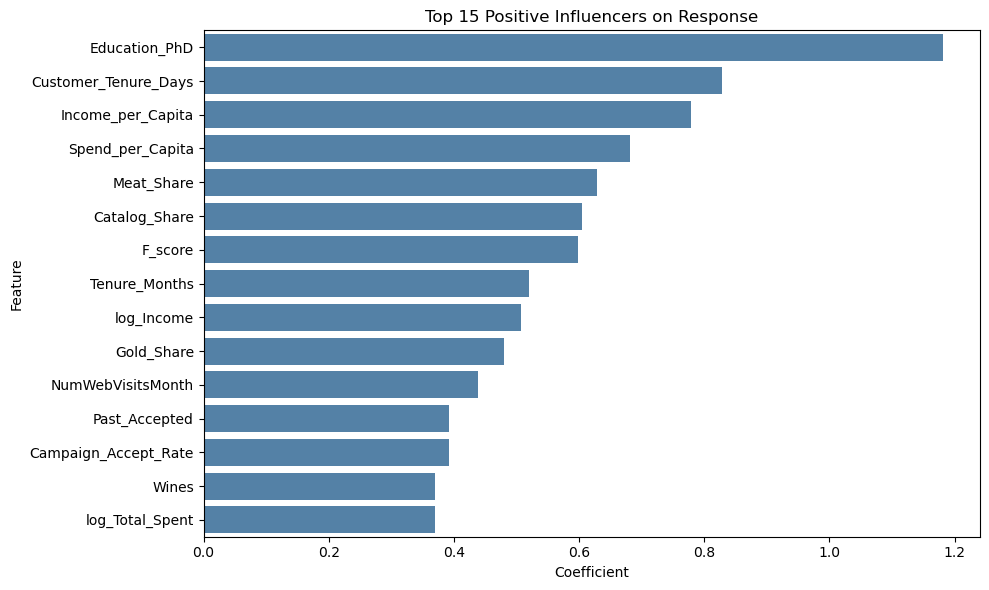

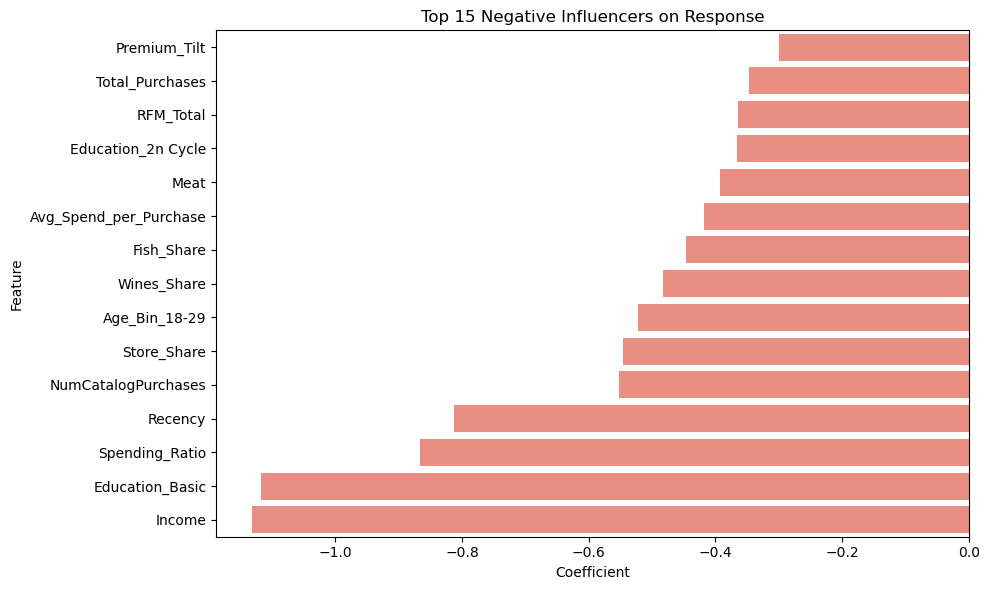


💾 Model saved to results_lr/logistic_regression_model.pkl
📈 Metrics saved to results_lr/metrics.txt

🔍 CRISP-DM Summary
1️⃣ Business Understanding → Predict customer campaign response.
2️⃣ Data Understanding → Includes socio-demographics & spending behavior.
3️⃣ Data Preparation → Missing values imputed, scaled, and encoded.
4️⃣ Modeling → Logistic Regression baseline.
5️⃣ Evaluation → Accuracy = 0.8919, AUC = 0.9120
6️⃣ Deployment → Model & results saved in /results_lr folder.


In [21]:
#Logistic Regression → baseline linear model
#Random Forest → nonlinear, ensemble model
# ================================================================
# LOGISTIC REGRESSION BASELINE MODEL (with Imputation + Saving)
# Dataset: customers_featured.csv
# Goal: Predict "Response" based on customer personality & RFM features
# Methodology: CRISP-DM
# ================================================================

# -----------------------------
# 1. IMPORT LIBRARIES
# -----------------------------
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    accuracy_score,
    roc_curve,
    auc
)
import warnings
warnings.filterwarnings('ignore')

# -----------------------------
# 2. LOAD & UNDERSTAND DATA
# -----------------------------
df = pd.read_csv("customers_featured.csv")

print("✅ Data Loaded Successfully!")
print(f"Shape: {df.shape}")
print(df.head(3))

# Handle missing values in target (if any)
df = df.dropna(subset=["Response"])

# Convert Response to binary if needed
if df["Response"].dtype == "object":
    df["Response"] = df["Response"].map({"Yes": 1, "No": 0})

# Drop ID-like columns
df = df.loc[:, ~df.columns.str.contains('ID', case=False)]

# Separate features/target
X = df.drop("Response", axis=1)
y = df["Response"]

# Identify categorical/numerical columns
categorical_cols = X.select_dtypes(include=["object", "category"]).columns.tolist()
numerical_cols = X.select_dtypes(include=["int64", "float64"]).columns.tolist()

print(f"\nCategorical Columns: {categorical_cols}")
print(f"Numerical Columns: {numerical_cols}")

# -----------------------------
# 3. DATA PREPROCESSING PIPELINE
# -----------------------------
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numerical_cols),
        ("cat", categorical_transformer, categorical_cols)
    ]
)

# -----------------------------
# 4. TRAIN-TEST SPLIT
# -----------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"\nTraining Samples: {X_train.shape[0]}")
print(f"Testing Samples: {X_test.shape[0]}")

# -----------------------------
# 5. MODELING
# -----------------------------
model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(max_iter=1000, random_state=42))
])

model.fit(X_train, y_train)
print("\n✅ Model training complete!")

# -----------------------------
# 6. EVALUATION
# -----------------------------
y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]

print("\n--- Classification Report ---")
print(classification_report(y_test, y_pred))
accuracy = accuracy_score(y_test, y_pred)
print(f"✅ Accuracy: {accuracy:.4f}")

# -----------------------------
# 7. VISUALIZATIONS (Save to results_lr/)
# -----------------------------
os.makedirs("results_lr", exist_ok=True)

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.savefig("results_lr/confusion_matrix.png", dpi=300)
plt.show()

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_proba)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6, 4))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}", color="darkorange")
plt.plot([0, 1], [0, 1], "k--")
plt.title("ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc="lower right")
plt.tight_layout()
plt.savefig("results_lr/roc_curve.png", dpi=300)
plt.show()

# -----------------------------
# 8. FEATURE IMPORTANCE
# -----------------------------
# Extract feature names
feature_names = (
    numerical_cols +
    list(model.named_steps["preprocessor"]
         .named_transformers_["cat"]
         .named_steps["encoder"]
         .get_feature_names_out(categorical_cols))
)

# Extract coefficients
coefficients = model.named_steps["classifier"].coef_[0]
importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": coefficients
}).sort_values("Coefficient", ascending=False)

# Save feature importance CSV
importance_df.to_csv("results_lr/feature_importance.csv", index=False)

# Plot top features
plt.figure(figsize=(10, 6))
sns.barplot(data=importance_df.head(15), x="Coefficient", y="Feature", color="steelblue")
plt.title("Top 15 Positive Influencers on Response")
plt.tight_layout()
plt.savefig("results_lr/top_positive_features.png", dpi=300)
plt.show()

plt.figure(figsize=(10, 6))
sns.barplot(data=importance_df.tail(15), x="Coefficient", y="Feature", color="salmon")
plt.title("Top 15 Negative Influencers on Response")
plt.tight_layout()
plt.savefig("results_lr/top_negative_features.png", dpi=300)
plt.show()

# -----------------------------
# 9. SAVE MODEL & METRICS
# -----------------------------
joblib.dump(model, "results_lr/logistic_regression_model.pkl")
print("\n💾 Model saved to results_lr/logistic_regression_model.pkl")

# Save metrics
with open("results_lr/metrics.txt", "w") as f:
    f.write(f"Accuracy: {accuracy:.4f}\n")
    f.write(f"AUC: {roc_auc:.4f}\n")
print("📈 Metrics saved to results_lr/metrics.txt")

# -----------------------------
# 10. CRISP-DM SUMMARY
# -----------------------------
print("\n🔍 CRISP-DM Summary")
print("1️⃣ Business Understanding → Predict customer campaign response.")
print("2️⃣ Data Understanding → Includes socio-demographics & spending behavior.")
print("3️⃣ Data Preparation → Missing values imputed, scaled, and encoded.")
print("4️⃣ Modeling → Logistic Regression baseline.")
print(f"5️⃣ Evaluation → Accuracy = {accuracy:.4f}, AUC = {roc_auc:.4f}")
print("6️⃣ Deployment → Model & results saved in /results_lr folder.")


✅ Data Loaded Successfully!
Shape: (2216, 64)
    Education  Has_Partner  Income  Recency  Wines  Fruits  Meat  Fish  \
0  Graduation            0   58138       58    635      88   546   172   
1  Graduation            0   46344       38     11       1     6     2   
2  Graduation            1   71613       26    426      49   127   111   

   Sweets  Gold  ...  R_score  F_score  M_score  RFM_Total  log_Income  \
0      88    88  ...      3.0      3.0      5.0       11.0   10.970592   
1       1     6  ...      4.0      3.0      1.0        8.0   10.743869   
2      21    42  ...      4.0      4.0      4.0       12.0   11.179046   

   log_Total_Spent  Income_x_HasPartner  Age_x_WebShare  Age_Bin  Income_q  
0         7.388946                    0       20.727273    45-59         2  
1         3.332205                    0       15.000000      60+         2  
2         6.655440                71613       19.600000    45-59         3  

[3 rows x 64 columns]

Categorical Columns: ['Educa

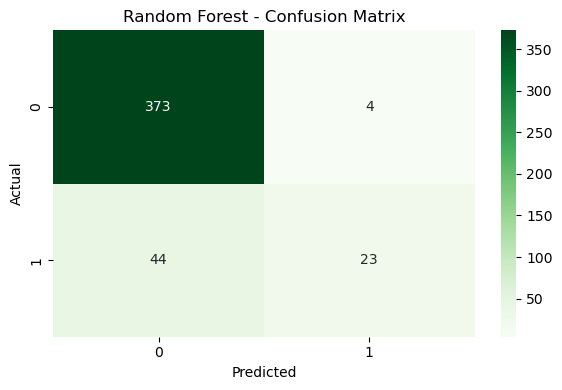

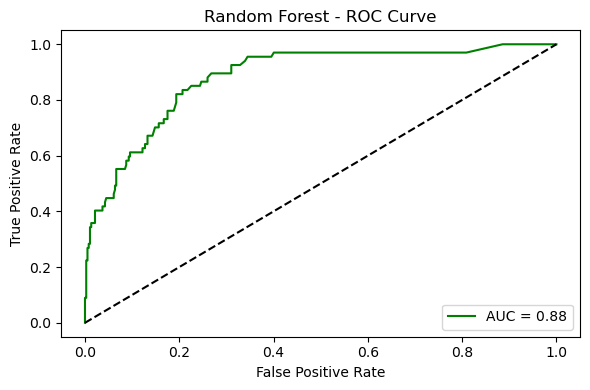

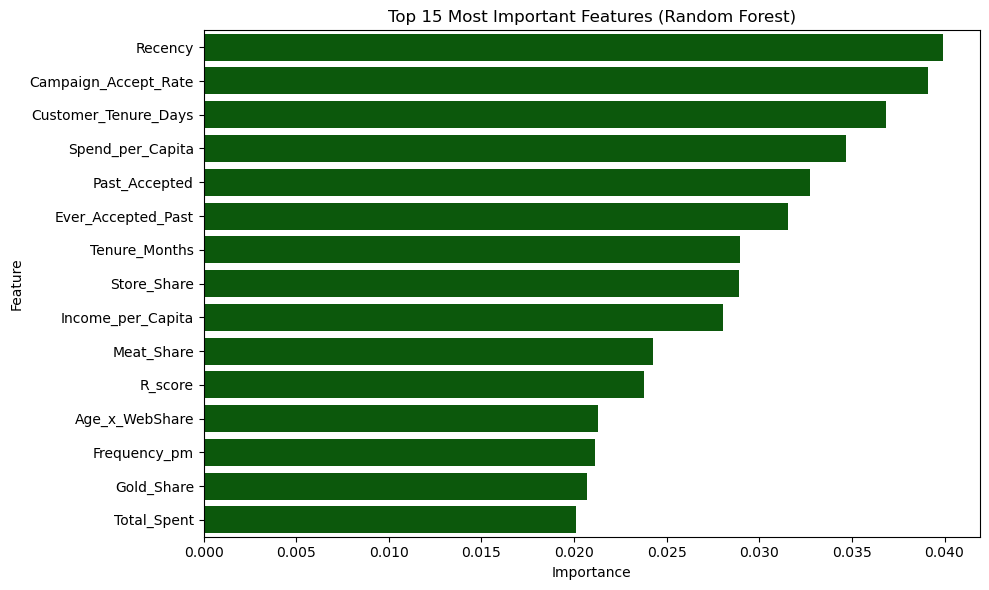


💾 Model saved to results_rf/random_forest_model.pkl
📈 Metrics saved to results_rf/metrics.txt

🔍 CRISP-DM Summary
1️⃣ Business Understanding → Predict customer campaign response.
2️⃣ Data Understanding → Personality and RFM features analyzed.
3️⃣ Data Preparation → Missing values imputed, features scaled and encoded.
4️⃣ Modeling → Random Forest Classifier (200 trees).
5️⃣ Evaluation → Accuracy = 0.8919, AUC = 0.8815
6️⃣ Deployment → Model & results saved in /results_rf folder.
7️⃣ Next Step → Compare with Logistic Regression to measure model uplift.


In [ ]:
# ================================================================
# RANDOM FOREST CLASSIFIER MODEL (CRISP-DM)
# Dataset: customers_featured.csv
# Goal: Predict "Response" column based on customer features
# ================================================================

# -----------------------------
# 1. IMPORT LIBRARIES
# -----------------------------
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    accuracy_score,
    roc_curve,
    auc
)
import warnings
warnings.filterwarnings('ignore')

# -----------------------------
# 2. LOAD & UNDERSTAND DATA
# -----------------------------
df = pd.read_csv("customers_featured.csv")

print("✅ Data Loaded Successfully!")
print(f"Shape: {df.shape}")
print(df.head(3))

# Handle missing values in target (if any)
df = df.dropna(subset=["Response"])

# Convert Response to binary if needed
if df["Response"].dtype == "object":
    df["Response"] = df["Response"].map({"Yes": 1, "No": 0})

# Drop ID-like columns
df = df.loc[:, ~df.columns.str.contains('ID', case=False)]

# Separate features/target
X = df.drop("Response", axis=1)
y = df["Response"]

# Identify categorical/numerical columns
categorical_cols = X.select_dtypes(include=["object", "category"]).columns.tolist()
numerical_cols = X.select_dtypes(include=["int64", "float64"]).columns.tolist()

print(f"\nCategorical Columns: {categorical_cols}")
print(f"Numerical Columns: {numerical_cols}")

# -----------------------------
# 3. DATA PREPROCESSING PIPELINE
# -----------------------------
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numerical_cols),
        ("cat", categorical_transformer, categorical_cols)
    ]
)

# -----------------------------
# 4. TRAIN-TEST SPLIT
# -----------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"\nTraining Samples: {X_train.shape[0]}")
print(f"Testing Samples: {X_test.shape[0]}")

# -----------------------------
# 5. MODELING
# -----------------------------
# Random Forest Classifier
rf_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(
        n_estimators=200,
        max_depth=None,
        min_samples_split=2,
        min_samples_leaf=1,
        random_state=42,
        n_jobs=-1
    ))
])

rf_model.fit(X_train, y_train)
print("\n✅ Random Forest training complete!")

# -----------------------------
# 6. EVALUATION
# -----------------------------
y_pred = rf_model.predict(X_test)
y_proba = rf_model.predict_proba(X_test)[:, 1]

print("\n--- Classification Report ---")
print(classification_report(y_test, y_pred))
accuracy = accuracy_score(y_test, y_pred)
print(f"✅ Accuracy: {accuracy:.4f}")

# -----------------------------
# 7. VISUALIZATIONS (Save to results/)
# -----------------------------
os.makedirs("results_rf", exist_ok=True)

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens')
plt.title("Random Forest - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.savefig("results_rf/confusion_matrix.png", dpi=300)
plt.show()

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_proba)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6, 4))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}", color="green")
plt.plot([0, 1], [0, 1], "k--")
plt.title("Random Forest - ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc="lower right")
plt.tight_layout()
plt.savefig("results_rf/roc_curve.png", dpi=300)
plt.show()

# -----------------------------
# 8. FEATURE IMPORTANCE
# -----------------------------
# Extract feature names (after preprocessing)
feature_names = (
    numerical_cols +
    list(rf_model.named_steps["preprocessor"]
         .named_transformers_["cat"]
         .named_steps["encoder"]
         .get_feature_names_out(categorical_cols))
)

# Extract importances
importances = rf_model.named_steps["classifier"].feature_importances_
importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
}).sort_values("Importance", ascending=False)

# Save feature importance CSV
importance_df.to_csv("results_rf/feature_importance.csv", index=False)

# Plot top features
plt.figure(figsize=(10, 6))
sns.barplot(data=importance_df.head(15), x="Importance", y="Feature", color="darkgreen")
plt.title("Top 15 Most Important Features (Random Forest)")
plt.tight_layout()
plt.savefig("results_rf/top_features.png", dpi=300)
plt.show()

# -----------------------------
# 9. SAVE MODEL & METRICS
# -----------------------------
joblib.dump(rf_model, "results_rf/random_forest_model.pkl")
print("\n💾 Model saved to results_rf/random_forest_model.pkl")

# Save metrics
with open("results_rf/metrics.txt", "w") as f:
    f.write(f"Accuracy: {accuracy:.4f}\n")
    f.write(f"AUC: {roc_auc:.4f}\n")
print("📈 Metrics saved to results_rf/metrics.txt")

# -----------------------------
# 10. CRISP-DM SUMMARY
# -----------------------------
print("\n🔍 CRISP-DM Summary")
print("1️⃣ Business Understanding → Predict customer campaign response.")
print("2️⃣ Data Understanding → Personality and RFM features analyzed.")
print("3️⃣ Data Preparation → Missing values imputed, features scaled and encoded.")
print("4️⃣ Modeling → Random Forest Classifier (200 trees).")
print(f"5️⃣ Evaluation → Accuracy = {accuracy:.4f}, AUC = {roc_auc:.4f}")
print("6️⃣ Deployment → Model & results saved in /results_rf folder.")
print("7️⃣ Next Step → Compare with Logistic Regression to measure model uplift.")


Train shape: (1772, 63) | Test shape: (444, 63)
Input features after encoding: 72
Epoch 1/70
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.7876 - loss: 0.6809 - val_accuracy: 0.8169 - val_loss: 0.6891
Epoch 2/70
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8582 - loss: 0.6772 - val_accuracy: 0.8169 - val_loss: 0.6854
Epoch 3/70
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8582 - loss: 0.6772 - val_accuracy: 0.8169 - val_loss: 0.6842
Epoch 4/70
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8582 - loss: 0.6771 - val_accuracy: 0.8169 - val_loss: 0.6828
Epoch 5/70
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8582 - loss: 0.6771 - val_accuracy: 0.8169 - val_loss: 0.6824
Epoch 6/70
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8582 - loss: 0.6770 - val_accuracy: 0.8169 - val_loss: 0.6791
Epoch 7/70
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8582 - loss: 0.6770 - val_accuracy: 0.8169 - val_loss: 0.6779
Epoch 8/70
45/45 ━━━━━━━━━━━━━━━━━━━

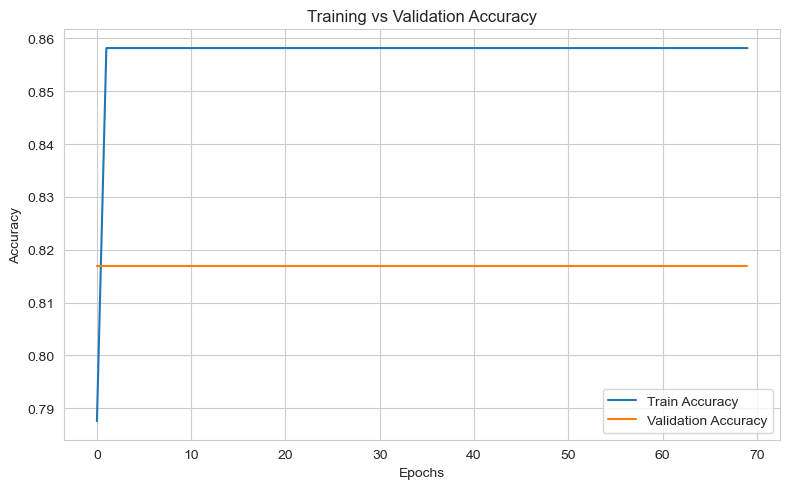

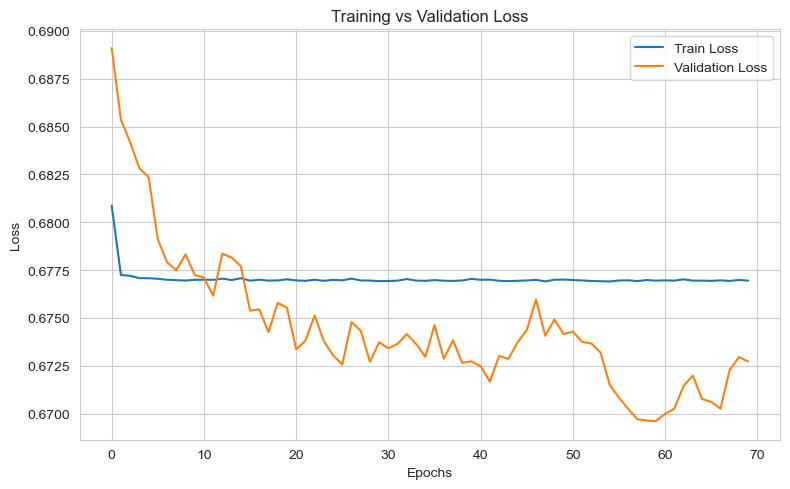

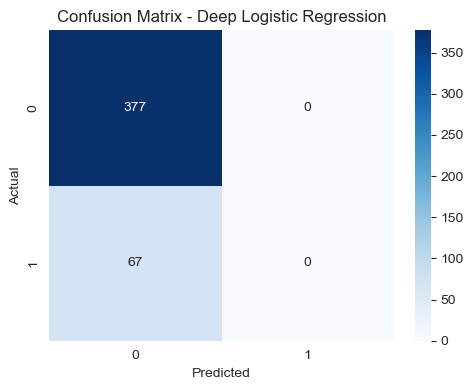


🔍 INTERPRETATION SUMMARY
1️⃣ This deep neural network extends the traditional Logistic Regression by introducing hidden layers.
2️⃣ These layers allow the model to capture nonlinear relationships between customer features.
3️⃣ Dropout layers act as regularization to prevent overfitting.
4️⃣ Batch normalization (if added) would stabilize training — optional for small networks.
5️⃣ Compare this model’s performance with the Random Forest and Deep RF-Equivalent models to assess improvements.


In [12]:
# ================================================================
# TASK: DEEP LEARNING LOGISTIC REGRESSION BASELINE
# Dataset: customers_featured.csv
# Target: Response
# ================================================================

# -----------------------------
# 1. IMPORT LIBRARIES
# -----------------------------
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score
from sklearn.utils import class_weight
import joblib
import warnings
import os

warnings.filterwarnings("ignore")

# Ensure results directory exists
os.makedirs("results_dl", exist_ok=True)

# -----------------------------
# 2. LOAD DATA
# -----------------------------
df = pd.read_csv("customers_featured.csv")

# Convert target to numeric if necessary
if df["Response"].dtype == "object":
    df["Response"] = df["Response"].map({"Yes": 1, "No": 0})

X = df.drop("Response", axis=1)
y = df["Response"]

# -----------------------------
# 3. TRAIN-TEST SPLIT
# -----------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"Train shape: {X_train.shape} | Test shape: {X_test.shape}")

# -----------------------------
# 4. PREPROCESSING PIPELINE
# -----------------------------
cat_features = X.select_dtypes(include=["object", "category"]).columns
num_features = X.select_dtypes(exclude=["object", "category"]).columns

preprocessor = ColumnTransformer(transformers=[
    ("num", StandardScaler(), num_features),
    ("cat", OneHotEncoder(handle_unknown="ignore"), cat_features)
])

# Fit and transform
X_train_prep = preprocessor.fit_transform(X_train)
X_test_prep = preprocessor.transform(X_test)

input_dim = X_train_prep.shape[1]
print(f"Input features after encoding: {input_dim}")

# Save preprocessor
joblib.dump(preprocessor, "results_dl/preprocessor_logreg_dl.pkl")

# -----------------------------
# 5. BUILD DEEP LEARNING MODEL
# -----------------------------
# This architecture mimics a "deep" logistic regression:
# - Shallow but non-linear model
# - Few hidden layers for feature interaction learning
model = Sequential([
    Dense(64, input_dim=input_dim, activation="relu"),
    Dropout(0.3),
    Dense(32, activation="relu"),
    Dense(1, activation="sigmoid")  # Output layer for binary classification
])

# Compile model
model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

# -----------------------------
# 6. TRAINING
# -----------------------------
# Compute class weights to handle imbalance
class_weights = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)
class_weights = dict(enumerate(class_weights))

# Train the model with validation split
history = model.fit(
    X_train_prep, y_train,
    validation_split=0.2,
    epochs=70,
    batch_size=32,
    class_weight=class_weights,
    verbose=1
)

# Save model
model.save("results_dl/deep_logistic_regression_model.keras")

# -----------------------------
# 7. EVALUATION
# -----------------------------
y_pred_proba = model.predict(X_test_prep)
y_pred = (y_pred_proba > 0.5).astype(int).flatten()

acc = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("\n✅ Deep Learning Logistic Regression Evaluation")
print(classification_report(y_test, y_pred))
print(f"Accuracy: {acc:.4f}")
print(f"F1 Score: {f1:.4f}")

# Save metrics
with open("results_dl/metrics_logreg_dl.txt", "w") as metrics_file:
    metrics_file.write(f"Accuracy: {acc:.4f}\n")
    metrics_file.write(f"F1 Score: {f1:.4f}\n")

# -----------------------------
# 8. VISUALIZATIONS
# -----------------------------
# Learning Curves
plt.figure(figsize=(8,5))
plt.plot(history.history["accuracy"], label="Train Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.title("Training vs Validation Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.tight_layout()
plt.savefig("results_dl/accuracy_curve_logreg_dl.png")
plt.show()

plt.figure(figsize=(8,5))
plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.title("Training vs Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.tight_layout()
plt.savefig("results_dl/loss_curve_logreg_dl.png")
plt.show()

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix - Deep Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.savefig("results_dl/confusion_matrix_logreg_dl.png")
plt.show()

# -----------------------------
# 9. INTERPRETATION SUMMARY
# -----------------------------
print("\n🔍 INTERPRETATION SUMMARY")
print("1️⃣ This deep neural network extends the traditional Logistic Regression by introducing hidden layers.")
print("2️⃣ These layers allow the model to capture nonlinear relationships between customer features.")
print("3️⃣ Dropout layers act as regularization to prevent overfitting.")
print("4️⃣ Batch normalization (if added) would stabilize training — optional for small networks.")
print("5️⃣ Compare this model’s performance with the Random Forest and Deep RF-Equivalent models to assess improvements.")


Dataset shape: (2216, 64)
Response value counts:
 Response
0    1883
1     333
Name: count, dtype: int64
Response distribution (normalized):
 Response
0    0.849729
1    0.150271
Name: proportion, dtype: float64

Categorical features: ['Education', 'Recency_Bin', 'Age_Bin']
Numerical features: ['Has_Partner', 'Income', 'Recency', 'Wines', 'Fruits', 'Meat', 'Fish', 'Sweets', 'Gold', 'NumDealsPurchases', 'NumWebPurchases', 'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth', 'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1', 'AcceptedCmp2', 'Complain', 'Age', 'Total_Spent', 'Spending_Ratio', 'Children_Home', 'Customer_Tenure_Days', 'Family_Size', 'Income_per_Capita', 'Spend_per_Capita', 'Dependency_Ratio', 'Wines_Share', 'Fruits_Share', 'Meat_Share', 'Fish_Share', 'Sweets_Share', 'Gold_Share', 'Num_Categories_Active', 'Category_Concentration', 'Premium_Tilt', 'Total_Purchases', 'Avg_Spend_per_Purchase', 'Web_Share', 'Catalog_Share', 'Store_Share', 'Deals_Share', 

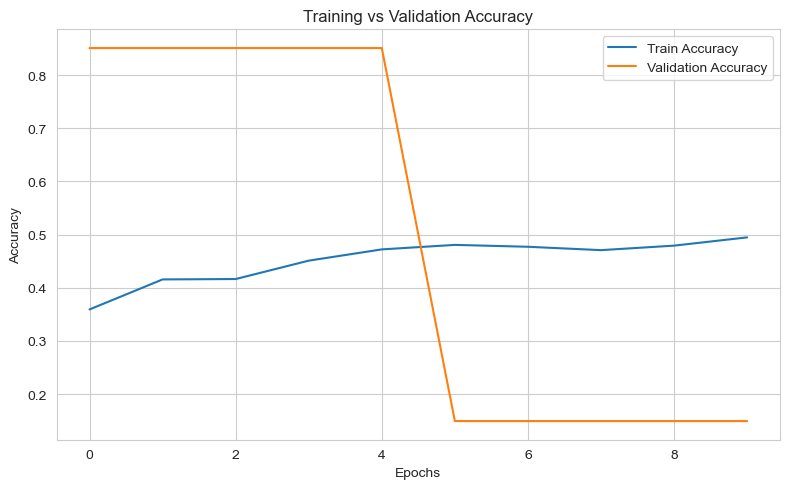

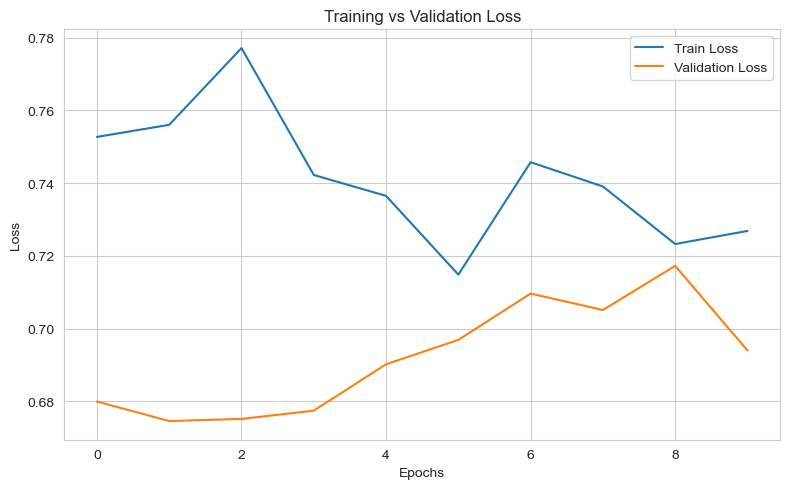

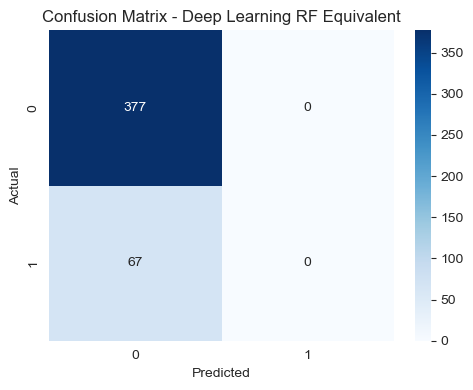


Sample preprocessed feature stats (first 5 dims):
Means: [-2.03499119e-16 -1.02000174e-16 -8.76524837e-17 -4.09754999e-17
 -8.70886007e-18]
Stds: [1. 1. 1. 1. 1.]
Saved training history and preprocessor.

🔍 REMARKS
• We used an explicit stratified validation set (no Keras validation_split).
• Preprocessing (StandardScaler + OneHot) is fitted only on training data.
• Class weights are computed from the training fold and applied during training.
• EarlyStopping + ModelCheckpoint restore best model by val_loss.
• All artifacts saved under results_dl/ (model, preprocessor, plots, metrics).


In [9]:
# ================================================================
# TASK 4: DEEP LEARNING CLASSIFIER (Random Forest Equivalent) - FIXED
# Dataset: customers_featured.csv
# Target: Response
# ================================================================

# -----------------------------
# 1. IMPORT LIBRARIES
# -----------------------------
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score
import joblib
import warnings
from sklearn.utils import class_weight
from sklearn.pipeline import Pipeline

warnings.filterwarnings("ignore")
sns.set_style("whitegrid")

# -----------------------------
# 2. CREATE RESULTS FOLDER
# -----------------------------
os.makedirs("results_dl", exist_ok=True)

# -----------------------------
# 3. LOAD DATA
# -----------------------------
df = pd.read_csv("customers_featured.csv")

# Ensure target is binary 0/1
if df["Response"].dtype == "object":
    df["Response"] = df["Response"].map({"Yes": 1, "No": 0})
df = df.dropna(subset=["Response"])  # drop rows missing target

# -----------------------------
# 4. BASIC SANITY CHECKS
# -----------------------------
print("Dataset shape:", df.shape)
print("Response value counts:\n", df["Response"].value_counts(normalize=False))
print("Response distribution (normalized):\n", df["Response"].value_counts(normalize=True))

# -----------------------------
# 5. DEFINE FEATURES & TARGET
# -----------------------------
X = df.drop("Response", axis=1)
y = df["Response"].astype(int)

# Identify categorical and numerical columns automatically
cat_features = X.select_dtypes(include=["object", "category"]).columns.tolist()
num_features = X.select_dtypes(include=["int64", "float64"]).columns.tolist()

print("\nCategorical features:", cat_features)
print("Numerical features:", num_features)

# -----------------------------
# 6. PREPROCESSING PIPELINE
# -----------------------------
numeric_transformer = Pipeline(steps=[
    ("scaler", StandardScaler())
])
categorical_transformer = Pipeline(steps=[
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(transformers=[
    ("num", numeric_transformer, num_features),
    ("cat", categorical_transformer, cat_features)
])

# -----------------------------
# 7. TRAIN/TEST SPLIT (outer)
# -----------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)
print(f"\nTrain shape: {X_train.shape} | Test shape: {X_test.shape}")
print("Train Response dist:", y_train.value_counts(normalize=True).to_dict())

# -----------------------------
# 8. FIT PREPROCESSOR & TRANSFORM
# -----------------------------
# Fit preprocessor on training set only
X_train_prep = preprocessor.fit_transform(X_train)
X_test_prep = preprocessor.transform(X_test)

# Input dimension after preprocessing
input_dim = X_train_prep.shape[1]
print(f"Input features after encoding: {input_dim}")

# Save the fitted preprocessor
joblib.dump(preprocessor, "results_dl/preprocessor_rf_dl.pkl")
print("Saved preprocessor to results_dl/preprocessor_rf_dl.pkl")

# Quick checks on preprocessed data
print("Any NaNs in X_train_prep?", np.isnan(X_train_prep).any())
print("Any infs in X_train_prep?", np.isinf(X_train_prep).any())
print("First 5 means:", np.mean(X_train_prep, axis=0)[:5])
print("First 5 stds:", np.std(X_train_prep, axis=0)[:5])

# -----------------------------
# 9. CREATE EXPLICIT VALIDATION SPLIT (from TRAIN set)
# -----------------------------
X_train_full, X_val, y_train_full, y_val = train_test_split(
    X_train_prep, y_train, test_size=0.20, random_state=42, stratify=y_train
)
print(f"\nAfter val split -> Train_full: {X_train_full.shape}, Val: {X_val.shape}")
print("Train_full Response dist:", pd.Series(y_train_full).value_counts(normalize=True).to_dict())
print("Val Response dist:", pd.Series(y_val).value_counts(normalize=True).to_dict())

# -----------------------------
# 10. COMPUTE CLASS WEIGHTS FROM TRAIN_FULL
# -----------------------------
cw = class_weight.compute_class_weight(
    class_weight="balanced",
    classes=np.unique(y_train_full),
    y=y_train_full
)
class_weights = dict(enumerate(cw))
print("\nClass weights:", class_weights)

# -----------------------------
# 11. BUILD THE DEEP MODEL (stable architecture)
# -----------------------------
def build_model(input_dim):
    model = Sequential([
        Dense(256, input_dim=input_dim, activation="relu"),
        BatchNormalization(),
        Dropout(0.3),

        Dense(128, activation="relu"),
        BatchNormalization(),
        Dropout(0.2),

        Dense(64, activation="relu"),
        BatchNormalization(),
        Dropout(0.2),

        Dense(32, activation="relu"),
        Dense(1, activation="sigmoid")
    ])
    # Slightly lower LR for more stable training
    opt = Adam(learning_rate=5e-4)
    model.compile(optimizer=opt, loss="binary_crossentropy", metrics=["accuracy"])
    return model

model = build_model(input_dim)

# -----------------------------
# 12. CALLBACKS: EarlyStopping + ModelCheckpoint
# -----------------------------
checkpoint_path = "results_dl/best_deep_rf_equivalent.keras"
callbacks = [
    EarlyStopping(monitor="val_loss", patience=8, restore_best_weights=True, verbose=1),
    ModelCheckpoint(checkpoint_path, monitor="val_loss", save_best_only=True, verbose=1)
]

# -----------------------------
# 13. TRAINING (use explicit validation_data)
# -----------------------------
history = model.fit(
    X_train_full, y_train_full,
    validation_data=(X_val, y_val),
    epochs=150,
    batch_size=32,
    shuffle=True,
    class_weight=class_weights,
    callbacks=callbacks,
    verbose=2
)

# Save final model (best weights were restored by EarlyStopping)
model.save("results_dl/deep_rf_equivalent_model.keras")
print("\nSaved final model to results_dl/deep_rf_equivalent_model.keras")
print("Best model (checkpoint) saved to:", checkpoint_path)

# -----------------------------
# 14. EVALUATION ON TEST SET
# -----------------------------
# Predict probabilities and threshold at 0.5
y_pred_proba = model.predict(X_test_prep).ravel()
y_pred = (y_pred_proba > 0.5).astype(int)

acc = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
print("\n✅ Deep Learning Random Forest Equivalent Evaluation")
print(classification_report(y_test, y_pred))
print(f"Accuracy: {acc:.4f}")
print(f"F1 Score: {f1:.4f}")

# Save metrics to file
with open("results_dl/metrics.txt", "w") as metrics_file:
    metrics_file.write(f"Accuracy: {acc:.4f}\n")
    metrics_file.write(f"F1 Score: {f1:.4f}\n")
# -----------------------------
# 15. VISUALIZATIONS (save plots)
# -----------------------------
# Learning curves
plt.figure(figsize=(8,5))
plt.plot(history.history["accuracy"], label="Train Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.title("Training vs Validation Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.tight_layout()
plt.savefig("results_dl/accuracy_curve.png", dpi=200)
plt.show()

plt.figure(figsize=(8,5))
plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.title("Training vs Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.tight_layout()
plt.savefig("results_dl/loss_curve.png", dpi=200)
plt.show()

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix - Deep Learning RF Equivalent")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.savefig("results_dl/confusion_matrix.png", dpi=200)
plt.show()

# -----------------------------
# 16. POST-TRAINING CHECKS / INTERPRETATION
# -----------------------------
# Print sample statistics of preprocessed features (sanity)
print("\nSample preprocessed feature stats (first 5 dims):")
print("Means:", np.mean(X_train_prep, axis=0)[:5])
print("Stds:", np.std(X_train_prep, axis=0)[:5])

# -----------------------------
# 17. SAVE HISTORY & PREPROCESSOR
# -----------------------------
# Save training history as CSV for reporting
hist_df = pd.DataFrame(history.history)
hist_df.to_csv("results_dl/training_history.csv", index=False)
joblib.dump(preprocessor, "results_dl/preprocessor_rf_dl.pkl")  # already saved earlier, safe to overwrite
print("Saved training history and preprocessor.")

# -----------------------------
# 18. FINAL REMARKS
# -----------------------------
print("\n🔍 REMARKS")
print("• We used an explicit stratified validation set (no Keras validation_split).")
print("• Preprocessing (StandardScaler + OneHot) is fitted only on training data.")
print("• Class weights are computed from the training fold and applied during training.")
print("• EarlyStopping + ModelCheckpoint restore best model by val_loss.")
print("• All artifacts saved under results_dl/ (model, preprocessor, plots, metrics).")
